# Projetos de Análise de Dados com Linguagem Python
# Projeto 02 - Técnicas de Engenharia de Atributos

## Pacotes Python Usados no Projeto

In [1]:
# Imports
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Carregando os Dados e Compreendendo as Variáveis

In [2]:
# Carregando os dados
df_2 = pd.read_csv("02_dataset.csv")

In [3]:
# Shape
df_2.shape

(101766, 50)

In [4]:
# Visualizando os dados
df_2.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222167,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
# Info
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

### Limpeza e Transformação dos Dados

In [6]:
# Verificando valores nulos (ausentes)
df_2.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [7]:
# Checando as colunas que tem valor = '?'
df_2.isin(['?']).any()

encounter_id                False
patient_nbr                 False
race                         True
gender                      False
age                         False
weight                       True
admission_type_id           False
discharge_disposition_id    False
admission_source_id         False
time_in_hospital            False
payer_code                   True
medical_specialty            True
num_lab_procedures          False
num_procedures              False
num_medications             False
number_outpatient           False
number_emergency            False
number_inpatient            False
diag_1                       True
diag_2                       True
diag_3                       True
number_diagnoses            False
max_glu_serum               False
A1Cresult                   False
metformin                   False
repaglinide                 False
nateglinide                 False
chlorpropamide              False
glimepiride                 False
acetohexamide 

In [8]:
df_2.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [9]:
# Verificando valores únicos
for col in list(df_2.columns):
    
    # Obtém uma lista de valores únicos
    list_of_unique_values = df_2[col].unique()
    
    # Se o número de valores exclusivos for menor que 15, imprima os valores. 
    # Caso contrário, imprima o número de valores exclusivos
    if len(list_of_unique_values) < 15:
        print("\n")
        print(col + ': ' + str(len(list_of_unique_values)) + ' valores únicos')
        print(list_of_unique_values)
    else:
        print("\n")
        print(col + ': ' + str(len(list_of_unique_values)) + ' valores únicos')



encounter_id: 101766 valores únicos


patient_nbr: 71518 valores únicos


race: 6 valores únicos
['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian' 'Hispanic']


gender: 3 valores únicos
['Female' 'Male' 'Unknown/Invalid']


age: 10 valores únicos
['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']


weight: 10 valores únicos
['?' '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']


admission_type_id: 8 valores únicos
[6 1 2 3 4 5 8 7]


discharge_disposition_id: 26 valores únicos


admission_source_id: 17 valores únicos


time_in_hospital: 14 valores únicos
[ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]


payer_code: 18 valores únicos


medical_specialty: 73 valores únicos


num_lab_procedures: 118 valores únicos


num_procedures: 7 valores únicos
[0 5 1 6 2 3 4]


num_medications: 75 valores únicos


number_outpatient: 39 valores únicos


number_emergency: 33 valores únicos


number_inpati

O caracter '?' nada mais é do que valor ausente. Vamos limpar isso.

In [10]:
# Vamos verificar a quantidade e percentual de registros onde o valor é igual a '?'
for col in df_2.columns:
    if df_2[col].dtype == object:
        if df_2[col][df_2[col] == '?'].count() > 0:
            print('\nColuna', col, 'tem', df_2[col][df_2[col] == '?'].count(), 'valores com o caracter "?"')
            print('Isso representa', round(df_2[col][df_2[col] == '?'].count() / len(df_2.index) * 100, 2), '% do total')



Coluna race tem 2273 valores com o caracter "?"
Isso representa 2.23 % do total

Coluna weight tem 98569 valores com o caracter "?"
Isso representa 96.86 % do total

Coluna payer_code tem 40256 valores com o caracter "?"
Isso representa 39.56 % do total

Coluna medical_specialty tem 49949 valores com o caracter "?"
Isso representa 49.08 % do total

Coluna diag_1 tem 21 valores com o caracter "?"
Isso representa 0.02 % do total

Coluna diag_2 tem 358 valores com o caracter "?"
Isso representa 0.35 % do total

Coluna diag_3 tem 1423 valores com o caracter "?"
Isso representa 1.4 % do total


In [11]:
# A coluna gender também apresenta um valor que precisamos tratar
print('\nColuna gender tem', df_2['gender'][df_2['gender'] == 'Unknown/Invalid'].count(), 'valores com "Unknown/Invalid"')
print('Isso representa', round(df_2['gender'][df_2['gender'] == 'Unknown/Invalid'].count() / len(df_2.index) * 100, 2), '% do total')


Coluna gender tem 3 valores com "Unknown/Invalid"
Isso representa 0.0 % do total


**Agora a parte importante - decidir o que fazer!**

- Há valores ausentes sobre peso do paciente em mais de 96% dos registros. 

- O código do pagador e a especialidade médica também apresentam valores ausentes de 40 a 50%. 

- As demais variáveis apresentam um baixo percentual de valores ausentes.

O que fazer?

**Alternativas:**

- Colocar a variável peso como categórica com dois labels: disponível / não disponível (1 e 0).
- Criar um código genérico para a variável payer_code como 99 e preencher os valores ausentes.
- Criar um tipo genérico para a variável medical_specialty como 'Sem Especialidade Definida' e preencher os valores ausentes.
- Para a variável gender são apenas 3 registros e o ideal é removê-los.

**Decisão:**

- 1- Devido à fraca interpretabilidade dos valores ausentes da variável peso, o melhor é simplesmente ignorar a variável e removê-la.

- 2- Vamos descartar as variáveis payer_code e medical_specialty, pois seria difícil tratar quantidade muito grande de valores ausentes.

- 3- Vamos remover os registros com "?" das demais variáveis.

- 4- Para a variável gender vamos remover os 3 registros com categoria "Unknown/Invalid".

<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->

In [12]:
# Removendo as 3 colunas com alto percentual de valores ausentes
df_2 = df_2.drop(['weight', 'payer_code', 'medical_specialty'], axis = 1)

Para as demais variáveis com baixo percentual de valores ausentes, removemos os registros.

In [13]:
# Removemos os registros com baixo percentual de valores ausentes
df_2 = df_2[df_2['race'] != '?']
df_2 = df_2[df_2['diag_1'] != '?']
df_2 = df_2[df_2['diag_2'] != '?']
df_2 = df_2[df_2['diag_3'] != '?']
df_2 = df_2[df_2['gender'] != 'Unknown/Invalid']

In [14]:
# Checando as colunas que tem valor = '?'
df_2.isin(['?']).any()

encounter_id                False
patient_nbr                 False
race                        False
gender                      False
age                         False
admission_type_id           False
discharge_disposition_id    False
admission_source_id         False
time_in_hospital            False
num_lab_procedures          False
num_procedures              False
num_medications             False
number_outpatient           False
number_emergency            False
number_inpatient            False
diag_1                      False
diag_2                      False
diag_3                      False
number_diagnoses            False
max_glu_serum               False
A1Cresult                   False
metformin                   False
repaglinide                 False
nateglinide                 False
chlorpropamide              False
glimepiride                 False
acetohexamide               False
glipizide                   False
glyburide                   False
tolbutamide   

In [15]:
# Shape
df_2.shape

(98052, 47)

Será que temos variáveis com um único valor?

In [16]:
# Visualiza os dados
df_2.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,Steady,No,No,No,No,No,No,Yes,>30


In [17]:
# Checando por variáveis com um único valor (ou seja, constante)
df_2.loc[:, df_2.nunique() == 1].head()

,examide,citoglipton,metformin-rosiglitazone
1,No,No,No
2,No,No,No
3,No,No,No
4,No,No,No
5,No,No,No


Vamos eliminar as colunas que têm apenas 1 valor único, pois elas não adicionam nada à nossa análise. Queremos analisar variáveis e não constantes.

In [18]:
# Removendoo variáveis com valores únicos
df_2 = df_2.loc[:, df_2.nunique() != 1]

In [19]:
# Shape
df_2.shape

(98052, 44)

In [20]:
# Calculando o número total de valores em cada coluna
total_valores = df_2.shape[0]

# Calculando o número de valores ausentes em cada coluna
valores_ausentes = df_2.isnull().sum()

# Calculando o percentual de valores ausentes em cada coluna
percentual_ausentes = (valores_ausentes / total_valores) * 100

# Exibe somente colunas com percentual maior do que zero
percentual_ausentes[percentual_ausentes > 0]

max_glu_serum    94.688533
A1Cresult        83.485294
dtype: float64

In [21]:
# Removendo as 2 colunas com alto percentual de valores ausentes
df_2 = df_2.drop(['max_glu_serum', 'A1Cresult'], axis = 1)

In [22]:
# Shape
df_2.shape

(98052, 42)

## Engenharia de Atributos

### Ajustando a Variável Alvo Para Estratificação de Risco

Uma readmissão hospitalar ocorre quando um paciente que recebe alta do hospital é readmitido novamente dentro de um certo período de tempo. As taxas de readmissão hospitalar para certas condições agora são consideradas um indicador da qualidade do hospital e também afetam negativamente o custo médico. 

Nossa variável alvo é 'readmiited'. Queremos saber se um paciente será readmitido no hospital ou não.

A variável possui os valores:

-- < 30 (readmissão em menos de 30 dias)

-- > 30 (readmissão em mais de 30 dias)

-- No   (sem readmissão)

Nós podemos combinar a readmissão antes de 30 dias e após 30 dias em uma categoria (valor 1 - classe positiva) e nenhuma readmissão em outra categoria (valor 0 - classe negativa) para tornar nosso problema classificação binária.

In [23]:
df_2.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,No,Up,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,No,Up,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,No,Steady,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,No,Steady,No,No,No,No,No,Yes,>30


In [24]:
df_2['readmitted'].value_counts()

readmitted
NO     52337
>30    34649
<30    11066
Name: count, dtype: int64

In [25]:
# Primeiro, vamos criar uma cópia do dataset até aqui
dados_clean1 = df_2.copy()

In [26]:
# Ajustando a variável alvo

# '0' significa que não foi readmitido
# '1' significa que foi readmitido, não importa quantos dias após a alta

df_2['readmitted'] = df_2['readmitted'].replace('>30', 1)
df_2['readmitted'] = df_2['readmitted'].replace('<30', 1)
df_2['readmitted'] = df_2['readmitted'].replace('NO', 0)

In [27]:
# Verifica os valores únicos
df_2['readmitted'].unique()

array([1, 0])

In [28]:
# Checa o tipo de dado
df_2['readmitted'].dtype

dtype('int64')

In [29]:
df_2.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,No,Up,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,No,Up,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,No,Steady,No,No,No,No,Ch,Yes,0
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,No,Steady,No,No,No,No,No,Yes,1


In [30]:
# Verifica a proporção de cada classe
round(df_2.readmitted.value_counts() / len(df_2.index) * 100, 0)

readmitted
0    53.0
1    47.0
Name: count, dtype: float64

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


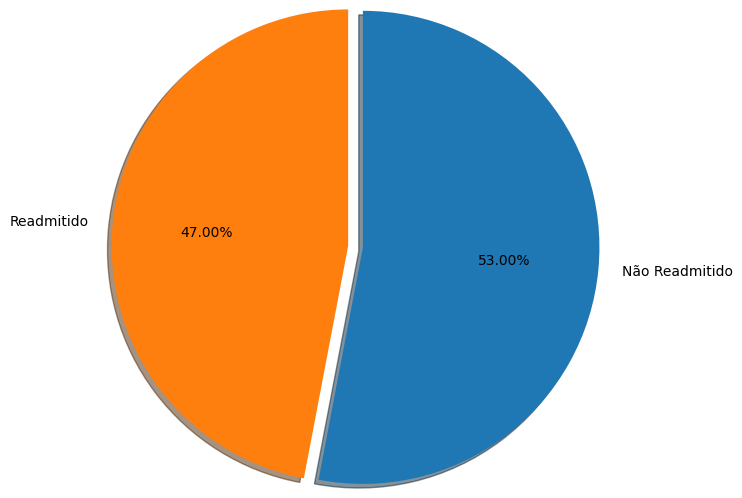

In [31]:
# Vamos visualizar de forma gráfica

# Percentual de cada valor da variável alvo
percentual = round(df_2.readmitted.value_counts() / len(df_2.index) * 100, 0)

# Labels
labels = ['Não Readmitido', 'Readmitido']

# Plot
plt.axis("equal")
plt.pie(percentual , 
        labels = labels,
        radius = 1.6,
        autopct = '%1.2f%%',
        explode = [0.05,0.05],
        startangle = 90,
        shadow = True,
        counterclock = False,
        pctdistance = 0.6)
plt.show()

Cerca de 47% dos pacientes de diabetes foram readmitidos nos hospitais.

### Recategorização de Variável

Como tratamos a variável idade?

In [32]:
# Tipo da variável
df_2.age.dtype

dtype('O')

In [33]:
# Total de pacientes por faixa etária
df_2.groupby('age').size()

age
[0-10)         65
[10-20)       466
[20-30)      1478
[30-40)      3548
[40-50)      9265
[50-60)     16697
[60-70)     21809
[70-80)     25305
[80-90)     16702
[90-100)     2717
dtype: int64

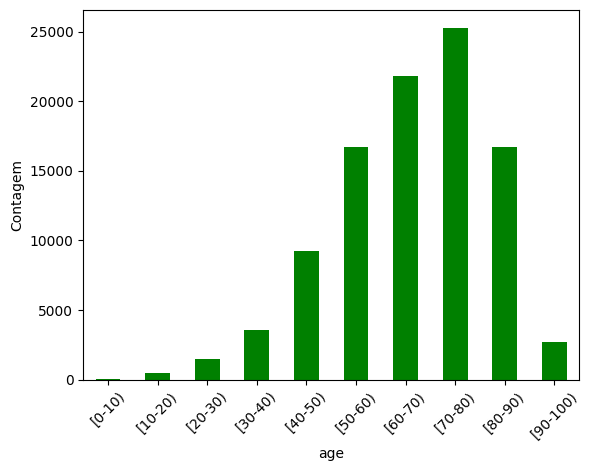

In [34]:
# Vamos verificar a variável que representa a faixa etária dos pacientes

# Agrupando os dados por idade e plotando o gráfico de barras
df_2.groupby('age').size().plot(kind = 'bar', color = 'green')

# Adicionando rótulo ao eixo y
plt.ylabel('Contagem')

# Rotacionando os rótulos do eixo x
plt.xticks(rotation = 45)

# Exibindo o gráfico
plt.show()

Podemos perceber que a maioria dos pacientes está na faixa entre 50 e 90 anos. 

Existem diferentes maneiras de lidar com essa variável. O conjunto de dados nos dá a idade apenas como categorias nas faixas de 10 anos, portanto, não sabemos a idade exata de cada paciente. 

Podemos adotar duas abordagens:

1- Se queremos ver o efeito do aumento da idade na readmissão do paciente, mesmo que de maneira grosseira, podemos assumir que a idade do paciente, em média, esteja no ponto médio da categoria de idade. Por exemplo, se a categoria de idade do paciente é de 20 a 30 anos, assumimos a idade = 25 anos. Então, convertemos categorias de idade em pontos médios, resultando em uma variável numérica.


2- Podemos recategorizar a variável, distribuindo os pacientes por um número menor de faixas e manter a variável como categórica. Nesse caso, poderíamos avaliar o risco por faixa etária e não por idade.

Adotaremos a opção 2 pois altera menos a informação contida nos dados.

In [35]:
# Recategorizamos 'idade' para que a população seja distribuída de maneira mais uniforme

# Classificamos como faixa de 0-50 pacientes de até 50 anos
df_2['age'] = pd.Series(['[0-50)' if val in ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)'] else val 
                          for val in df_2['age']], index = df_2.index)

# Acima de 80 anos ficam na faixa de 80-100
df_2['age'] = pd.Series(['[80-100)' if val in ['[80-90)', '[90-100)'] else val 
                          for val in df_2['age']], index = df_2.index)

# As outras faixas são mantidas

In [36]:
# Tipo ds variável
df_2.age.dtype

dtype('O')

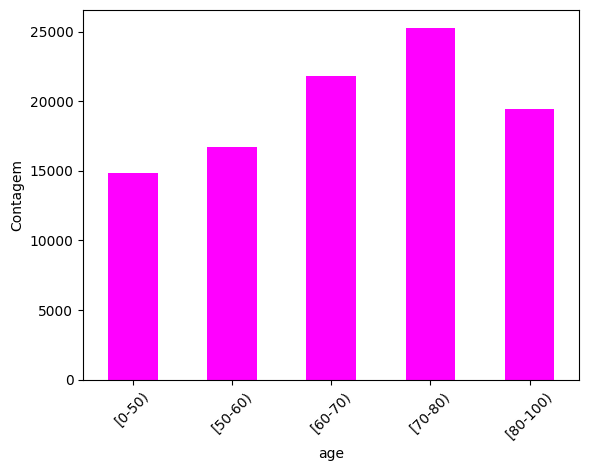

In [37]:
# Vamos verificar a variável que representa a faixa etária dos pacientes

# Agrupando os dados por idade e plotando o gráfico de barras
df_2.groupby('age').size().plot(kind = 'bar', color = 'magenta')

# Adicionando rótulo ao eixo y
plt.ylabel('Contagem')

# Rotacionando os rótulos do eixo x
plt.xticks(rotation = 45)

# Exibindo o gráfico
plt.show()

Como tratamos variáveis do tipo ID? Seguiremos com a Recategorização de Variável.

As variáveis 'admission_type_id', 'harge_disposition_id' e 'admission_source_id' têm valores com significado semelhante. Eles podem ser mesclados para ter menos valores.

In [38]:
# Visualiza
df_2.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[0-50),1,1,7,3,59,...,No,No,Up,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[0-50),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[0-50),1,1,7,2,44,...,No,No,Up,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[0-50),1,1,7,1,51,...,No,No,Steady,No,No,No,No,Ch,Yes,0
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,No,Steady,No,No,No,No,No,Yes,1


Variável **admission_type_id**

In [39]:
df_2.admission_type_id.unique()

array([1, 2, 3, 6, 4, 5, 8, 7])

In [40]:
df_2.admission_type_id.nunique()

8

In [41]:
df_2.admission_type_id.value_counts()

admission_type_id
1    52178
3    18193
2    17543
6     5135
5     4661
8      312
7       20
4       10
Name: count, dtype: int64

In [42]:
# A variável 'admission_type_id' contém 8 níveis
# Reduziremos os níveis de 'admission_type_id' para duas categorias
df_2['admission_type_id'] = pd.Series(['Emergencia' if val == 1 else 'Outro' 
                                        for val in df_2['admission_type_id']], index = df_2.index)

In [43]:
df_2.admission_type_id.nunique()

2

In [44]:
df_2.admission_type_id.value_counts()

admission_type_id
Emergencia    52178
Outro         45874
Name: count, dtype: int64

Variável **discharge_disposition_id**

In [45]:
df_2.discharge_disposition_id.unique()

array([ 1,  3,  6,  2,  5, 11,  7, 25, 10,  4, 14, 18,  8, 13, 12, 16, 17,
       22, 23,  9, 20, 15, 24, 28, 19, 27])

In [46]:
df_2.discharge_disposition_id.nunique()

26

In [47]:
df_2.discharge_disposition_id.value_counts()

discharge_disposition_id
1     57609
3     13564
6     12626
18     3624
2      2049
22     1970
11     1606
5      1127
25      941
4       756
7       592
23      400
13      396
14      368
28      137
8       106
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

In [48]:
# A variável 'discharge_disposition_id' contém 26 níveis
# Reduziremos os níveis de 'discharge_disposition_id' para duas categorias
df_2['discharge_disposition_id'] = pd.Series(['Casa' if val == 1 else 'Outro' 
                                              for val in df_2['discharge_disposition_id']], index = df_2.index)

In [49]:
df_2.discharge_disposition_id.nunique()

2

In [50]:
df_2.discharge_disposition_id.value_counts()

discharge_disposition_id
Casa     57609
Outro    40443
Name: count, dtype: int64

Variável **admission_source_id**

In [51]:
df_2.admission_source_id.unique()

array([ 7,  2,  4,  1,  5,  6, 20,  3, 17,  8,  9, 14, 10, 22, 11, 25, 13])

In [52]:
df_2.admission_source_id.nunique()

17

In [53]:
df_2.admission_source_id.value_counts()

admission_source_id
7     55951
1     28355
17     6602
4      2945
6      1893
2      1031
5       846
3       179
20      160
9        49
8        15
22       12
10        7
14        2
11        2
25        2
13        1
Name: count, dtype: int64

In [54]:
# A variável 'admission_source_id' contém 17 níveis
# # Reduziremos os níveis de 'admission_source_id' para três categorias
df_2['admission_source_id'] = pd.Series(['Sala_Emergencia' if val == 7 else 'Recomendacao' if val == 1 else 'Outro' 
                                              for val in df_2['admission_source_id']], index = df_2.index)


In [55]:
df_2.admission_source_id.nunique()

3

In [56]:
df_2.admission_source_id.value_counts()

admission_source_id
Sala_Emergencia    55951
Recomendacao       28355
Outro              13746
Name: count, dtype: int64

### Engenharia de Atributos com Base no Conhecimento de Domínio

Como tratamos as variáveis 'diag_1', 'diag_2' e 'diag_3' que representam o diagnóstico médico?

In [57]:
# Visualiza os dados
df_2[['diag_1', 'diag_2', 'diag_3']].head()

,diag_1,diag_2,diag_3
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250


O conjunto de dados contém até três diagnósticos para um determinado paciente (primário, secundário e adicional). 

No entanto, cada um deles tem códigos ICD-9 exclusivos e é extremamente difícil incluí-los no modelo e interpretar de forma significativa. 

Portanto, reduziremos esses códigos de diagnóstico para 4 categorias considerando a comorbidade.

Códigos ICD-9 (International Classification of Diseases ou Código Internacional de Doenças):

https://en.wikipedia.org/wiki/List_of_ICD-9_codes

http://www.icd9data.com/2013/Volume1/default.htm

https://icd.codes/icd9cm

https://www.cms.gov/Medicare/Coding/ICD9ProviderDiagnosticCodes/codes

In [58]:
# Concatena 3 variáveis em um dataframe
diagnostico = df_2[['diag_1', 'diag_2', 'diag_3']]

In [59]:
# Visualiza os dados
diagnostico.head(10)

,diag_1,diag_2,diag_3
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250
6,414,411,V45
7,428,492,250
8,398,427,38
9,434,198,486
10,250.7,403,996


In [60]:
# Verifica se há valores ausentes
diagnostico.isnull().any()

diag_1    False
diag_2    False
diag_3    False
dtype: bool

### Calculando a Comorbidade com Engenharia de Atributos

Defining Comorbidity: Implications for Understanding Health and Health Services:

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2713155/


Comorbidity: Substance Use Disorders and Other Mental Illnesses:

https://www.drugabuse.gov/publications/drugfacts/comorbidity-substance-use-disorders-other-mental-illnesses

Em termos simples, comorbidade refere-se à presença de mais de um distúrbio na mesma pessoa. Por exemplo, se uma pessoa é diagnosticada com transtorno de ansiedade social (SAD) e transtorno depressivo maior (MDD), diz-se que ela possui transtornos depressivos e ansiosos comórbidos (significando de coexistentes). 

Outras condições que parecem se sobrepor incluem doenças físicas como diabetes, doenças cardiovasculares, câncer, doenças infecciosas e demência. Os transtornos mentais que tendem a mostrar comorbidade também incluem transtornos alimentares, transtornos de ansiedade e abuso de substâncias.

Não é incomum que as pessoas sofram de dois distúrbios ou doenças ao mesmo tempo. A comorbidade na doença mental pode incluir uma situação em que uma pessoa recebe um diagnóstico médico seguido pelo diagnóstico de um transtorno mental (ou vice-versa) ou pode envolver o diagnóstico de um transtorno mental seguido pelo diagnóstico de outro transtorno mental.

Um grande estudo epidemiológico nacional transversal de 2009 sobre comorbidade de transtornos mentais na atenção primária na Espanha, publicado no Journal of Affective Disorders, mostrou que entre uma amostra de 7936 pacientes adultos, cerca da metade tinha mais de um distúrbio psiquiátrico.

<a href="https://www.sciencedirect.com/science/article/abs/pii/S016503270900127X?via%3Dihub">Prevalence and comorbidity of common mental disorders in primary care</a>

Além disso, uma Pesquisa Nacional de Comorbidade dos EUA, 51% dos pacientes com diagnóstico de depressão também tiveram pelo menos um transtorno de ansiedade e apenas 26% deles não tiveram nenhum outro transtorno mental. No entanto, no Estágio Inicial de Desenvolvimento da Psicopatologia, 48,6% dos pacientes com diagnóstico de depressão também apresentaram pelo menos um transtorno de ansiedade e 34,8% deles não possuíam outro transtorno mental.

<a href="https://www.cambridge.org/core/journals/the-british-journal-of-psychiatry/article/psychiatric-comorbidity-an-artefact-of-current-diagnostic-systems/9DAFC6B16152FFE0F297E4A9DB0A1674/core-reader">‘Psychiatric comorbidity’: an artefact of current diagnostic systems?</a>

Acesse o site abaixo para buscar detalhes sobre os padrões de expressões regulares em Python:

https://www.w3schools.com/python/python_regex.asp

In [61]:
# Visualiza os dados
diagnostico.head(10)

,diag_1,diag_2,diag_3
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250
6,414,411,V45
7,428,492,250
8,398,427,38
9,434,198,486
10,250.7,403,996


In [62]:
# Função que calcula a Comorbidade
def calcula_comorbidade(row):
    
    # Código 250 indica diabetes
    codigos_doenca_diabetes = "^[2][5][0]"
    
    # Códigos 39x (x = valor entre 0 e 9)
    # Códigos 4zx (z = valor entre 0 e 6 e x = valor entre 0 e 9)
    # Esses códigos indicam problemas circulatórios
    codigos_doenca_circulatorios = "^[3][9][0-9]|^[4][0-6][0-9]"
    
    # Inicializa variável de retorno
    valor = 0
    
    # Valor 0 indica que:
    # Diabetes e problemas circulatórios não foram detectados de forma simultânea no paciente
    if(not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_1']))))) and
       not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_2']))))) and 
       not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_3'])))))) and (not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_1']))))) and not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_2']))))) and not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_3'])))))):
        valor = 0
        
    # Valor 1 indica que:
    # Pelo menos um diagnóstico de diabetes e problemas circulatórios foram detectados de forma 
    # simultânea no paciente
    if(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_1'])))) or 
       bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_2'])))) or 
       bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_3']))))) and (not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_1']))))) and not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_2']))))) and not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_3'])))))): 
        valor = 1
        
    # Valor 2 indica que:
    # Diabetes e pelo menos um diagnóstico de problemas circulatórios foram detectados de forma 
    # simultânea no paciente
    if(not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_1']))))) and
       not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_2']))))) and 
       not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_3'])))))) and (
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_1'])))) or 
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_2'])))) or 
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_3']))))):
        valor = 2
        
    # Valor 3 indica que:
    # Pelo menos um diagnóstico de diabetes e pelo menos um diagnóstico de problemas circulatórios 
    # foram detectados de forma simultânea no paciente
    if(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_1'])))) or 
       bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_2'])))) or 
       bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_3']))))) and (
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_1'])))) or 
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_2'])))) or 
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_3']))))):
        valor = 3 
    
    return valor

> Agora aplicamos a função aos dados!

In [63]:
%%time
df_2['comorbidade'] = diagnostico.apply(calcula_comorbidade, axis = 1)

CPU times: total: 13.1 s
Wall time: 13.2 s


In [64]:
# Shape
df_2.shape

(98052, 43)

In [65]:
# Visualiza os dados
df_2.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,comorbidade
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,No,Up,No,No,No,No,Ch,Yes,1,1
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,No,No,No,No,No,No,No,Yes,0,1
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,No,Up,No,No,No,No,Ch,Yes,0,3
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,No,Steady,No,No,No,No,Ch,Yes,0,1
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,No,Steady,No,No,No,No,No,Yes,1,3


In [66]:
# Valores únicos
df_2['comorbidade'].unique()

array([1, 3, 2, 0])

In [67]:
# Valores únicos contagem
df_2['comorbidade'].value_counts()

comorbidade
2    39807
0    22389
1    17984
3    17872
Name: count, dtype: int64

In [68]:
# Drop das variáveis individuais
df_2.drop(['diag_1','diag_2','diag_3'], axis = 1, inplace = True)

In [69]:
# Calcula o percentual de comorbidade por tipo e por classe da variável alvo
percent_com = pd.crosstab(df_2.comorbidade, df_2.readmitted , normalize = 'index') * 100

In [70]:
percent_com

readmitted,0,1
comorbidade,,
0,55.509402,44.490598
1,53.831183,46.168817
2,51.782350,48.217650
3,53.799239,46.200761


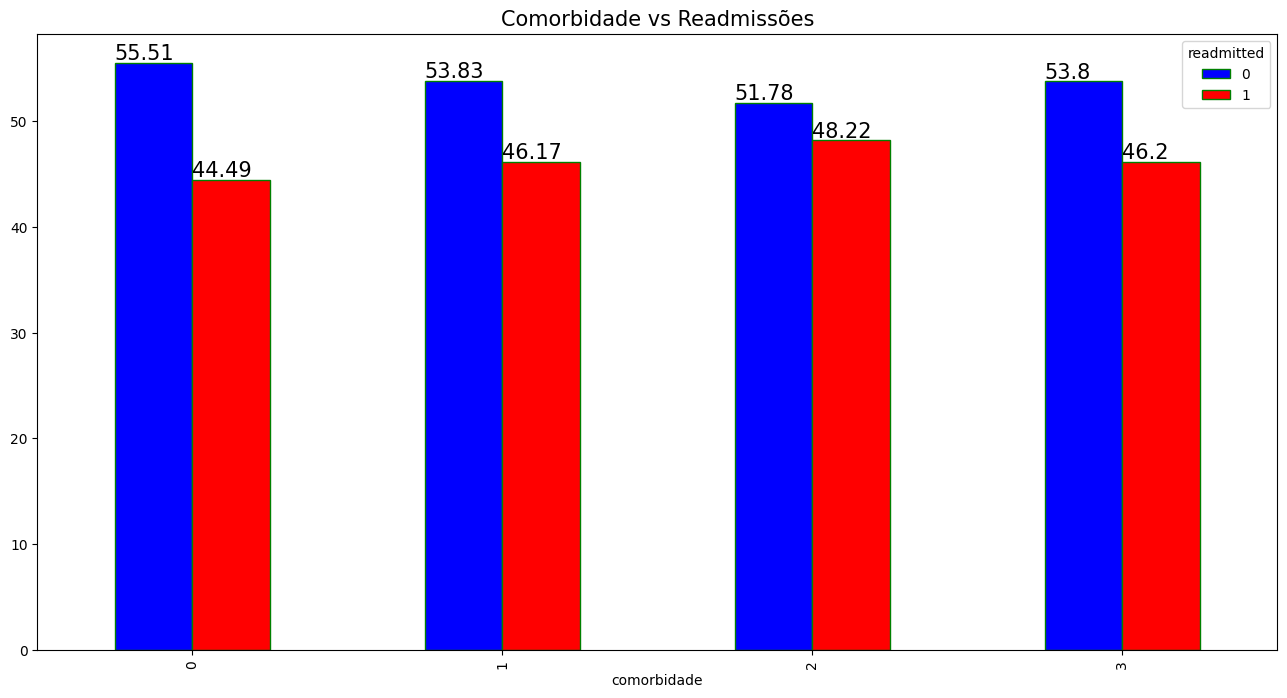

In [71]:
# Plot

# Prepara a figura a partir dos dados
fig = percent_com.plot(kind = 'bar', 
                       figsize = (16, 8), 
                       width = 0.5, 
                       edgecolor = 'g', 
                       color = ['b','r'])

# Desenha cada grupo
for i in fig .patches:
    fig.text(i.get_x() + 0.00, 
             i.get_height() + 0.3, 
             str(round((i.get_height()), 2)), 
             fontsize = 15, 
             color = 'black',
             rotation = 0)

# Título e Print
plt.title("Comorbidade vs Readmissões", fontsize = 15)
plt.show()

### Engenharia de Atributos - Recoding de Variáveis Categóricas

**Variáveis de Dosagem de Medicamentos e Agrupamento de Variáveis**

Verificando nosso conjunto de dados até aqui:

In [72]:
df_2.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,comorbidade
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,No,Up,No,No,No,No,Ch,Yes,1,1
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,No,No,No,No,No,No,No,Yes,0,1
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,No,Up,No,No,No,No,Ch,Yes,0,3
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,No,Steady,No,No,No,No,Ch,Yes,0,1
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,No,Steady,No,No,No,No,No,Yes,1,3


In [73]:
df_2.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted', 'comorbidade'],
      dtype='object')

O conjunto de dados contém 23 recursos para 23 medicamentos que indicam, para cada um deles, se uma alteração no medicamento foi feita ou não durante a atual internação do paciente. 

Vamos plotar algumas variáveis que indicam uso de medicamento.

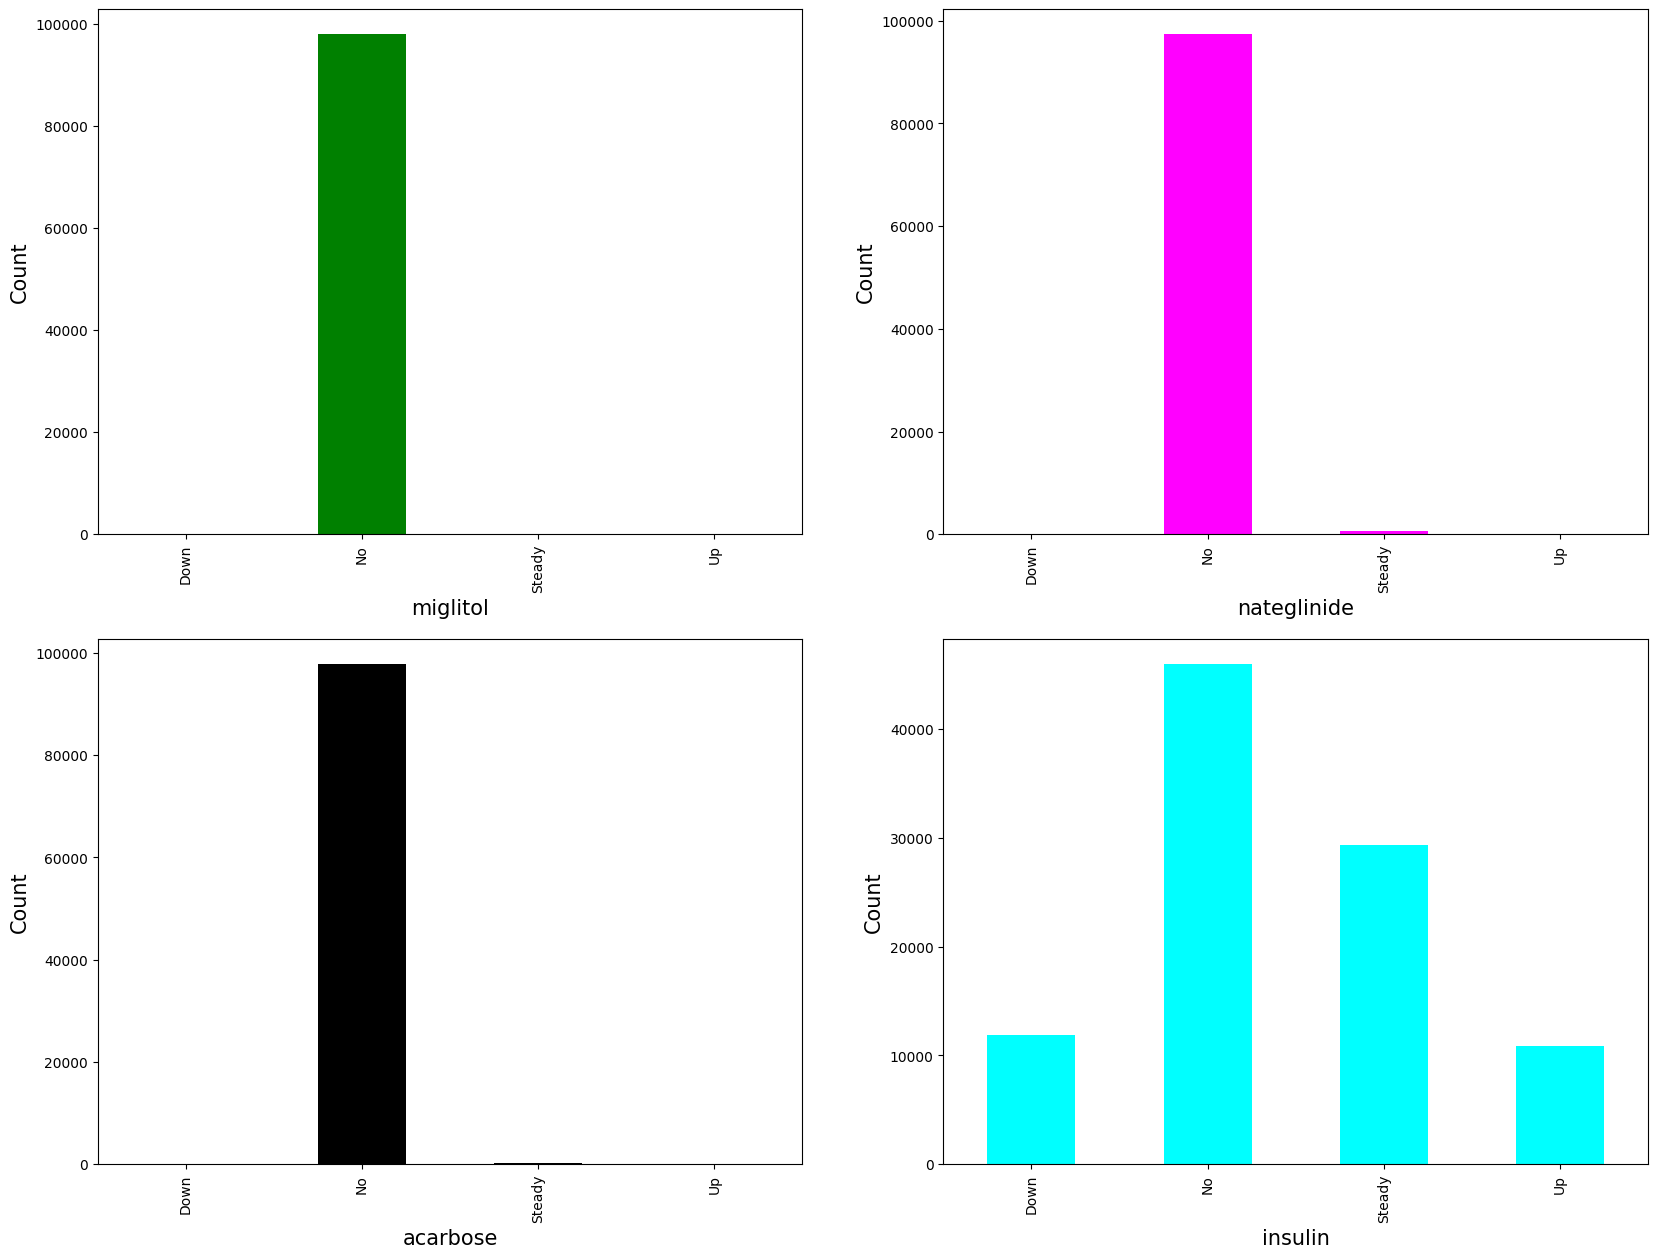

In [74]:
# Plot
fig = plt.figure(figsize = (20,15))

ax1 = fig.add_subplot(221)
ax1 = df_2.groupby('miglitol').size().plot(kind = 'bar', color = 'green')
plt.xlabel('miglitol', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

ax2 = fig.add_subplot(222)
ax2 = df_2.groupby('nateglinide').size().plot(kind = 'bar', color = 'magenta')
plt.xlabel('nateglinide', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

ax3 = fig.add_subplot(223)
ax3 = df_2.groupby('acarbose').size().plot(kind = 'bar', color = 'black')
plt.xlabel('acarbose', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

ax4 = fig.add_subplot(224)
ax4 = df_2.groupby('insulin').size().plot(kind = 'bar', color = 'cyan')
plt.xlabel('insulin', fontsize = 15)
plt.ylabel('Count', fontsize = 15)
plt.show();

Podemos contar quantas alterações do medicamento foram feitas no total para cada paciente e criamos um novo atributo. Isso pode ajudar a descobrir uma relação com o número de alterações, independentemente de qual medicamento foi alterado.

Além disso, podemos criar um novo atributo indicando o total de medicamentos que cada paciente consumiu durante a internação. E então avaliamos se há relação do total com a readmissão.

In [75]:
# Lista com os nomes das variáveis de medicamentos (3 variáveis já tinham sido removidas)
medicamentos = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 
                'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 
                'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 
                'glimepiride-pioglitazone', 'metformin-pioglitazone']

In [76]:
# Loop para ajustar o valor das variáveis
for col in medicamentos:
    if col in df_2.columns:
        colname = str(col) + 'temp'
        df_2[colname] = df_2[col].apply(lambda x: 0 if (x == 'No' or x == 'Steady') else 1)

In [77]:
df_2.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,rosiglitazonetemp,acarbosetemp,miglitoltemp,troglitazonetemp,tolazamidetemp,insulintemp,glyburide-metformintemp,glipizide-metformintemp,glimepiride-pioglitazonetemp,metformin-pioglitazonetemp
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,0,0,0,0,0,1,0,0,0,0
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,0,0,0,0,0,0,0,0,0,0
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,0,0,0,0,0,1,0,0,0,0
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,0,0,0,0,0,0,0,0,0,0
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,0,0,0,0,0,0,0,0,0,0


In [78]:
# Cria uma variável para receber a contagem por paciente
df_2['num_alt_dosagem_med'] = 0

In [79]:
# Contagem de modificações na dosagem de medicamentos
for col in medicamentos:
    if col in df_2.columns:
        colname = str(col) + 'temp'
        df_2['num_alt_dosagem_med'] = df_2['num_alt_dosagem_med'] + df_2[colname]
        del df_2[colname]

In [80]:
# Verifica o total por modificações na dosagem de medicamentos
df_2.num_alt_dosagem_med.value_counts()

num_alt_dosagem_med
0    71309
1    25350
2     1281
3      107
4        5
Name: count, dtype: int64

In [81]:
df_2.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,comorbidade,num_alt_dosagem_med
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,Up,No,No,No,No,Ch,Yes,1,1,1
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,No,No,No,No,No,No,Yes,0,1,0
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,Up,No,No,No,No,Ch,Yes,0,3,1
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,Steady,No,No,No,No,Ch,Yes,0,1,0
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,Steady,No,No,No,No,No,Yes,1,3,0


Vamos alterar o valor das colunas dos medicamentos para refletir se esse medicamento está sendo administrado a um paciente ou não.

In [82]:
# Recoding das colunas de medicamentos
for col in medicamentos:
    if col in df_2.columns:
        df_2[col] = df_2[col].replace('No', 0)
        df_2[col] = df_2[col].replace('Steady', 1)
        df_2[col] = df_2[col].replace('Up', 1)
        df_2[col] = df_2[col].replace('Down', 1) 

Agora, criamos mais uma coluna para refletir quantos medicamentos estão sendo administrados a um paciente.

In [83]:
# Variável com a contagem de medicamentos por paciente
df_2['num_med'] = 0

In [84]:
# Carregamos a nova variável
for col in medicamentos:
    if col in df_2.columns:
        df_2['num_med'] = df_2['num_med'] + df_2[col]

In [85]:
# Verifica o total de medicamentos
df_2['num_med'].value_counts()

num_med
1    45447
0    22702
2    21056
3     7485
4     1300
5       57
6        5
Name: count, dtype: int64

Depois de criar essas duas colunas, podemos remover as colunas dos medicamentos.

In [86]:
# Remove as colunas de medicamentos
df_2 = df_2.drop(columns = medicamentos)

In [87]:
# Shape
df_2.shape

(98052, 22)

In [88]:
df_2.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_outpatient,number_emergency,number_inpatient,number_diagnoses,change,diabetesMed,readmitted,comorbidade,num_alt_dosagem_med,num_med
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,0,0,0,9,Ch,Yes,1,1,1,1
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,2,0,1,6,No,Yes,0,1,0,1
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,0,0,0,7,Ch,Yes,0,3,1,1
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,0,0,0,5,Ch,Yes,0,1,0,2
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,0,0,0,9,No,Yes,1,3,0,1


In [89]:
# Variáveis
df_2.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
number_diagnoses             int64
change                      object
diabetesMed                 object
readmitted                   int64
comorbidade                  int64
num_alt_dosagem_med          int64
num_med                      int64
dtype: object

**Recoding de Variáveis Categóricas**

Vamos fazer o recoding de algumas variáveis categóricas.

In [90]:
df_2['change'].value_counts()

change
No    52774
Ch    45278
Name: count, dtype: int64

In [91]:
df_2['gender'].value_counts()

gender
Female    52833
Male      45219
Name: count, dtype: int64

In [92]:
df_2['diabetesMed'].value_counts()

diabetesMed
Yes    75350
No     22702
Name: count, dtype: int64

In [93]:
# Recoding de variáveis categóricas binárias
df_2['change'] = df_2['change'].replace('Ch', 1)
df_2['change'] = df_2['change'].replace('No', 0)
df_2['gender'] = df_2['gender'].replace('Male', 1)
df_2['gender'] = df_2['gender'].replace('Female', 0)
df_2['diabetesMed'] = df_2['diabetesMed'].replace('Yes', 1)
df_2['diabetesMed'] = df_2['diabetesMed'].replace('No', 0)

In [94]:
df_2.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_outpatient,number_emergency,number_inpatient,number_diagnoses,change,diabetesMed,readmitted,comorbidade,num_alt_dosagem_med,num_med
1,149190,55629189,Caucasian,0,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,0,0,0,9,1,1,1,1,1,1
2,64410,86047875,AfricanAmerican,0,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,2,0,1,6,0,1,0,1,0,1
3,500364,82442376,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,0,0,0,7,1,1,0,3,1,1
4,16680,42519267,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,0,0,0,5,1,1,0,1,0,2
5,35754,82637451,Caucasian,1,[50-60),Outro,Casa,Outro,3,31,...,0,0,0,9,0,1,1,3,0,1


Alguns pacientes no conjunto de dados tiveram mais de um encontro (consulta). 

Não podemos contá-los como encontros independentes, porque isso influencia os resultados para aqueles pacientes que tiveram vários encontros. Assim, tentamos várias técnicas para recolher e consolidar vários encontros para o mesmo paciente, como:

- Considerar a permanência média no hospital em vários encontros.
- Considerar a porcentagem de alterações na medicação em vários encontros.
- Considerar o número total de encontros para substituir o ID exclusivo do encontro.
- Considerar a combinação de diagnósticos em vários encontros como uma lista.

Por fim, o ideal foi deixar apenas um registro de encontro para cada paciente e optamos por manter o primeiro.

In [95]:
# Removendo duplicidades por id de paciente, mantendo o primeiro registro
df_2 = df_2.drop_duplicates(subset = ['patient_nbr'], keep = 'first')

In [96]:
# Shape
df_2.shape

(68629, 22)

In [97]:
df_2.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_outpatient,number_emergency,number_inpatient,number_diagnoses,change,diabetesMed,readmitted,comorbidade,num_alt_dosagem_med,num_med
1,149190,55629189,Caucasian,0,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,0,0,0,9,1,1,1,1,1,1
2,64410,86047875,AfricanAmerican,0,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,2,0,1,6,0,1,0,1,0,1
3,500364,82442376,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,0,0,0,7,1,1,0,3,1,1
4,16680,42519267,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,0,0,0,5,1,1,0,1,0,2
5,35754,82637451,Caucasian,1,[50-60),Outro,Casa,Outro,3,31,...,0,0,0,9,0,1,1,3,0,1


In [98]:
# Salvando o dataset
df_2.to_csv('02_resultado_projeto.csv', index = False)